In [20]:
%reload_ext autoreload
%autoreload 2
%cd ~/erc-src/cuneiform-ocr-sign-alignment-worktree # Change to the project directory
%env PATH=$HOME/.local/bin:$PATH
    
import json
import os
import requests
import numpy as np
import cv2
from PIL import Image
from pymongo import MongoClient
# from mmdet.apis import init_detector, inference_detector
# from mmdet.utils import register_all_modules
from data_processing.divide_photos import divide_tablet_photo
from sign_alignment.detector import ModelConfig, TabletImageDetector

# import signs_alignment as sa
import os
import torch
from dotenv import load_dotenv

ANNOTATIONS_DIR = os.path.expanduser("~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations")
CONFIG_FILE = "configs/detr.py"
CHECKPOINT_FILE = os.path.expanduser("~/erc-work-data/retrained_models/detr-173/epoch_1000.pth")
SCORE_THRESHOLD = 0.5
Y_THRESHOLD = 35  # for grouping signs into lines
OUTPUT_DIR = "alignment_results"
SAMPLE_LIMIT = 5  # number of samples to process

load_dotenv()
MONGODB_URI = os.getenv('MONGODB_URI', 'YOUR_MONGODB_URI')

[Errno 2] No such file or directory: '/home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree # Change to the project directory'
/home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree
env: PATH=$HOME/.local/bin:$PATH


In [21]:
model_config = ModelConfig(
    config_file=CONFIG_FILE,
    checkpoint_file=CHECKPOINT_FILE,
    device='auto'
)
tablet_detector = TabletImageDetector(
    model_config=model_config,
    score_threshold=SCORE_THRESHOLD,
    keep_crops=True
)

Initializing detector, loading model...
Using device: cuda:0
Loads checkpoint by local backend from path: /home/jebediahc/erc-work-data/retrained_models/detr-173/epoch_1000.pth


In [22]:
from sign_alignment.data_source import LocalDataSource

local_source = LocalDataSource(ANNOTATIONS_DIR)
fragments = local_source.get_available_fragments()
print(f"Found {len(fragments)} fragments with both image and annotation")
sample = fragments[0]
print(f"Processing sample: {sample}")

Found 947 fragments with both image and annotation
Processing sample: NBC.4020


In [ ]:
# show groud truth boxes
from sign_alignment.visualizer import BboxVisualizer

img = local_source.load_image(sample)
gt_boxes = local_source.load_annotation(sample)
print(f"Ground truth boxes: {gt_boxes}")

gt_bbox_visualizer = BboxVisualizer(color=(0, 255, 0)) # green for gt
gt_bbox_visualizer.draw_boxes(img.copy(), gt_boxes)
# gt_bbox_visualizer.display_result(vis_opt = "save", path = )
gt_bbox_visualizer.show_draw()
gt_bbox_visualizer.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_gt.jpg"))


In [24]:
# sign text
from sign_alignment.data_source import EBLAPISource, SignTextParser
from sign_alignment.visualizer import TextVisualizer

api_source = EBLAPISource()
signs_text = api_source.get_signs(sample)
if signs_text is None:
    raise ValueError(f"No sign text found for sample {sample}")
print(f"  Raw API signs (first 50 chars): {signs_text[:50]}...")

text_lines = SignTextParser.parse_api_signs(signs_text)
total_text_signs = sum(len(line) for line in text_lines)
print(f"  Text lines: {len(text_lines)}, total signs: {total_text_signs}")
# print all text lines
TextVisualizer.save_text(text_lines, path=os.path.join(OUTPUT_DIR, f"debug_{sample}_text.txt"), fragment_id=sample)

  Raw API signs (first 50 chars): ABZ579 ABZ70 ABZ371 ABZ586 ABZ6
ABZ461 ABZ214 ABZ3...
  Text lines: 22, total signs: 143


In [ ]:
# detect signs
from sign_alignment.visualizer import BboxVisualizer

# Use tablet_detector created in cell 2
detections = tablet_detector.detect(img)

det_bbox_visualizer = BboxVisualizer(color=(255, 0, 0)) # red for detections
det_bbox_visualizer.draw_boxes(img.copy(), detections)
det_bbox_visualizer.display_result(vis_opt = "save", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_det.jpg"))

cropped = tablet_detector.get_cropped_images()
exp_image = cropped[3]


det_bbox_visualizer.draw_boxes(exp_image.img.copy(), exp_image.detections)
det_bbox_visualizer.display_result(vis_opt = "draw", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_image.jpg"))

In [26]:
# Transform GT boxes for exp_image (cropped region)
from sign_alignment import transform_gt_to_cropped_region

# exp_image is cropped[3], so we need crop_coordinates[3]
exp_image_idx = 3
crop_info = tablet_detector.crop_coordinates[exp_image_idx]

print(f"Crop info for exp_image (index {exp_image_idx}): x={crop_info['x']}, y={crop_info['y']}, w={crop_info['w']}, h={crop_info['h']}")

# Transform GT boxes to exp_image coordinates
gt_boxes_exp = transform_gt_to_cropped_region(gt_boxes, crop_info)
print(f"GT boxes in full image: {len(gt_boxes)}")
print(f"GT boxes in exp_image: {len(gt_boxes_exp)}")

# Visualize GT boxes on exp_image
if gt_boxes_exp:
    gt_exp_bbox_visualizer = BboxVisualizer(color=(0, 255, 255))  # cyan for gt
    gt_exp_bbox_visualizer.draw_boxes(exp_image.img.copy(), gt_boxes_exp)
    gt_exp_bbox_visualizer.display_result(vis_opt="save", path=os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_gt.jpg"))

Crop info for exp_image (index 3): x=2200, y=1124, w=1817, h=1636
GT boxes in full image: 98
GT boxes in exp_image: 40
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_NBC.4020_exp_gt.jpg


In [27]:
# statistics
from sign_alignment import compute_avg_dimensions

avg_width, avg_height = compute_avg_dimensions(detections)
print(f"full image shape: {img.shape}")
print(f"Exp image shape: {exp_image.img.shape}")
print(f"Average detected sign width: {avg_width:.2f}, height: {avg_height:.2f}")

full image shape: (6451, 5078, 3)
Exp image shape: (1636, 1817, 3)
Average detected sign width: 227.35, height: 196.96


In [28]:
# Build heatmap for position probability of each class
from sign_alignment import create_detection_heatmap, CLASSES_ABZ

scale_factor = 10

# Create detection heatmap
heatmap, influence_radius, sigma = create_detection_heatmap(
    exp_image.detections, 
    exp_image.img.shape, 
    scale_factor=scale_factor,
    avg_width=avg_width,
    avg_height=avg_height,
    method='gaussian'
)

print(f"Original image shape: {exp_image.img.shape[:2]}")
print(f"Created heatmap with shape: {heatmap.shape}")
print(f"Scale factor: 1/{scale_factor}")
print(f"Number of CLASSES_ABZ: {len(CLASSES_ABZ)}")
print(f"Influence radius (scaled): {influence_radius:.2f}, sigma: {sigma:.2f}")
print(f"Heatmap generated with {len(exp_image.detections)} detections")
print(f"Heatmap value range: [{heatmap.min():.3f}, {heatmap.max():.3f}]")

Original image shape: (1636, 1817)
Created heatmap with shape: (163, 181, 173)
Scale factor: 1/10
Number of CLASSES_ABZ: 173
Influence radius (scaled): 31.82, sigma: 36.85
Heatmap generated with 43 detections
Heatmap value range: [0.000, 0.668]


In [ ]:
# Visualize exp image heatmap 
from sign_alignment import HeatmapVisualizer, SignResolver

heatmap_visualizer = HeatmapVisualizer()

# find class id for sign name "A"
class_id_for_A = None
class_id_for_NA = None
for i, abz_name in enumerate(CLASSES_ABZ):
    if SignResolver.from_abz(abz_name).name == "A":
        class_id_for_A = i
        break
for i, abz_name in enumerate(CLASSES_ABZ):
    if SignResolver.from_abz(abz_name).name == "NA":
        class_id_for_NA = i
        break
print(f"Class ID for sign 'A': {class_id_for_A}")
print(f"Class ID for sign 'NA': {class_id_for_NA}")
    
heatmap_visualizer.draw_channels(exp_image.img, heatmap, channels=(class_id_for_A, class_id_for_NA, 2), detection=exp_image.detections)
heatmap_visualizer.display_result(vis_opt="draw")
heatmap_visualizer.draw_pca(exp_image.img, heatmap, detection=exp_image.detections)
heatmap_visualizer.display_result(vis_opt="draw")

In [30]:
# Create heatmap from text_lines with synthetic sign positions
from sign_alignment import create_text_heatmap

# Create text heatmap (classes_abz defaults to CLASSES_ABZ)
heatmap_text, margin, influence_radius_text, sigma_text = create_text_heatmap(
    text_lines, 
    avg_width, 
    avg_height, 
    scale_factor=scale_factor,
    method='gaussian'
)

max_row_length = max(len(line) for line in text_lines)
num_rows = len(text_lines)
total_signs_in_text = sum(len(line) for line in text_lines)

print(f"Text lines grid: {num_rows} rows, max {max_row_length} columns")
print(f"Average sign dimensions: width={avg_width:.2f}, height={avg_height:.2f}")
print(f"Text heatmap dimensions (after scaling): {heatmap_text.shape}")
print(f"Margin used: {margin:.2f}")
print(f"Gaussian parameters - influence radius: {influence_radius_text:.2f}, sigma: {sigma_text:.2f}")
print(f"Heatmap generated for {total_signs_in_text} signs from text_lines")
print(f"Heatmap value range: [{heatmap_text.min():.3f}, {heatmap_text.max():.3f}]")

Text lines grid: 22 rows, max 12 columns
Average sign dimensions: width=227.35, height=196.96
Text heatmap dimensions (after scaling): (478, 318, 173)
Margin used: 227.35
Gaussian parameters - influence radius: 84.86, sigma: 30.31
Heatmap generated for 143 signs from text_lines
Heatmap value range: [0.000, 0.281]


In [ ]:
# Visualize text_lines heatmap

heatmap_visualizer_text = HeatmapVisualizer()
heatmap_visualizer_text.draw_channels(None, heatmap_text, 
                                      channels=(class_id_for_A, class_id_for_NA, 2), 
                                      detection=None, text_lines=text_lines)
heatmap_visualizer_text.display_result(vis_opt="draw")

In [32]:
# 1. Use normalized cross-correlation to find template position
from sign_alignment import match_heatmaps_ncc

print(f"Exp heatmap shape: {heatmap.shape}")
print(f"Text heatmap shape: {heatmap_text.shape}")

top_left_scaled, max_val, top_left_original = match_heatmaps_ncc(
    heatmap, 
    heatmap_text, 
    scale_factor=scale_factor
)

top_left_x_text = top_left_original[0]
top_left_y_text = top_left_original[1]

print(f"Best match correlation (averaged over {heatmap.shape[2]} classes): {max_val:.4f}")
print(f"Match position in text heatmap (scaled): {top_left_scaled}")
print(f"Match position in text heatmap (original): ({top_left_x_text:.2f}, {top_left_y_text:.2f})")

# Convert to full tablet image coordinates
top_left_x_tablet = top_left_x_text - margin
top_left_y_tablet = top_left_y_text - margin

print(f"Match position in full tablet image: ({top_left_x_tablet:.2f}, {top_left_y_tablet:.2f})")

Exp heatmap shape: (163, 181, 173)
Text heatmap shape: (478, 318, 173)
Best match correlation (averaged over 173 classes): 0.3610
Match position in text heatmap (scaled): (9, 18)
Match position in text heatmap (original): (90.00, 180.00)
Match position in full tablet image: (-137.35, -47.35)


In [ ]:
# 2. Visualize the position of exp image heatmap in text heatmap

# Create visualization using the mixed heatmaps for display
heatmap_exp_mixed = np.mean(heatmap, axis=2)
heatmap_text_mixed = np.mean(heatmap_text, axis=2)

vis_text_heatmap = cv2.normalize(heatmap_text_mixed, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
vis_text_heatmap_rgb = cv2.cvtColor(vis_text_heatmap, cv2.COLOR_GRAY2RGB)

# Draw rectangle at matched position (in scaled coordinates)
bottom_right_scaled = (top_left_scaled[0] + heatmap_exp_mixed.shape[1], 
                       top_left_scaled[1] + heatmap_exp_mixed.shape[0])
cv2.rectangle(vis_text_heatmap_rgb, top_left_scaled, bottom_right_scaled, (0, 255, 0), 2)

# Display
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
plt.imshow(vis_text_heatmap_rgb)
plt.title(f"Text Heatmap with Matched Exp Image Position (green box)\nCorrelation: {max_val:.4f}")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Green box shows matched position of exp image in text heatmap")

In [34]:
# 3. Assign sign centers from text image into exp image and create bboxes
from sign_alignment import create_text_based_detections

exp_img_height, exp_img_width = exp_image.img.shape[:2]

detection_with_texts = create_text_based_detections(
    text_lines, 
    top_left_x_text, 
    top_left_y_text, 
    margin, 
    avg_width, 
    avg_height, 
    (exp_img_width, exp_img_height)
)

print(f"Created {len(detection_with_texts)} text-based detections for exp image")
print(f"Original detections: {len(exp_image.detections)}")

# Show first few detections as example
if detection_with_texts:
    print("\nFirst 3 text-based detections:")
    for i, det in enumerate(detection_with_texts[:3]):
        print(f"  {i+1}. {det.sign.abz}: bbox=[{det.x1:.1f}, {det.y1:.1f}, {det.x2:.1f}, {det.y2:.1f}], "
              f"center=({(det.x1+det.x2)/2:.1f}, {(det.y1+det.y2)/2:.1f})")

Created 49 text-based detections for exp image
Original detections: 43

First 3 text-based detections:
  1. ABZ579: bbox=[137.3, 47.3, 364.7, 244.3], center=(251.0, 145.8)
  2. ABZ70: bbox=[364.7, 47.3, 592.0, 244.3], center=(478.4, 145.8)
  3. ABZ371: bbox=[592.0, 47.3, 819.4, 244.3], center=(705.7, 145.8)


In [ ]:
# 4. Visualize detection_with_texts for exp image

text_det_bbox_visualizer = BboxVisualizer(color=(0, 0, 255))  # blue for text-based detections
text_det_bbox_visualizer.draw_boxes(exp_image.img.copy(), detection_with_texts)
text_det_bbox_visualizer.display_result(vis_opt="draw", path=os.path.join(OUTPUT_DIR, f"debug_{sample}_text_detections.jpg"))

print(f"Visualized {len(detection_with_texts)} text-based detections on exp image")

In [37]:
# 5. Organize data using SubTablet data structures
from sign_alignment import SubTablet

# --- 1. Create SubTablet for detection results (exp_image) ---
sub_tablet_detection = SubTablet.from_detections(
    img=exp_image.img,
    detections=exp_image.detections,
    name="detection",
    avg_width=avg_width,
    avg_height=avg_height
)

# Generate heatmap for detection
sub_tablet_detection.create_heatmap(scale_factor=scale_factor, method='gaussian')

print(f"=== SubTablet: Detection ===")
print(f"  Name: {sub_tablet_detection.name}")
print(f"  Image shape: {sub_tablet_detection.shape}")
print(f"  Num sign boxes: {len(sub_tablet_detection)}")
print(f"  Avg dimensions: {sub_tablet_detection.avg_width:.2f} x {sub_tablet_detection.avg_height:.2f}")
print(f"  Heatmap shape: {sub_tablet_detection.heatmap.shape}")

# --- 2. Create SubTablet for full text (hypothetical full tablet from API text) ---
sub_tablet_full_text = SubTablet.from_text_lines(
    text_lines=text_lines,
    avg_width=avg_width,
    avg_height=avg_height,
    margin=margin,
    name="full_text"
)

# Generate heatmap for full text
sub_tablet_full_text.create_heatmap(scale_factor=scale_factor, method='gaussian')

print(f"\n=== SubTablet: Full Text ===")
print(f"  Name: {sub_tablet_full_text.name}")
print(f"  Estimated shape: {sub_tablet_full_text.shape}")
print(f"  Num sign boxes: {len(sub_tablet_full_text)}")
print(f"  Margin: {sub_tablet_full_text.margin:.2f}")
print(f"  Heatmap shape: {sub_tablet_full_text.heatmap.shape}")

# --- 3. Create SubTablet for text-aligned signs ---
sub_tablet_text_aligned = sub_tablet_full_text.extract_sub_region(
    offset_x=top_left_x_text,
    offset_y=top_left_y_text,
    width=exp_img_width,
    height=exp_img_height,
    img=exp_image.img,
    name="text_aligned"
)

# Generate heatmap for text-aligned (using image dimensions)
sub_tablet_text_aligned.create_heatmap(
    scale_factor=scale_factor,
    img_shape=exp_image.img.shape,
    method='gaussian'
)

print(f"\n=== SubTablet: Text Aligned ===")
print(f"  Name: {sub_tablet_text_aligned.name}")
print(f"  Image shape: {sub_tablet_text_aligned.shape}")
print(f"  Num sign boxes: {len(sub_tablet_text_aligned)}")
print(f"  Origin offset: ({sub_tablet_text_aligned.origin_x:.2f}, {sub_tablet_text_aligned.origin_y:.2f})")
print(f"  Heatmap shape: {sub_tablet_text_aligned.heatmap.shape}")

# --- Verify consistency ---
print(f"\n=== Verification ===")
print(f"  detection_with_texts count: {len(detection_with_texts)}")
print(f"  sub_tablet_text_aligned count: {len(sub_tablet_text_aligned)}")

print(f"\n  First 3 from sub_tablet_detection:")
for i, sb in enumerate(sub_tablet_detection.sign_boxes[:3]):
    print(f"    {i+1}. {sb.sign_name}: center=({sb.cx:.1f}, {sb.cy:.1f}), size=({sb.width:.1f}, {sb.height:.1f})")

print(f"\n  First 3 from sub_tablet_text_aligned:")
for i, sb in enumerate(sub_tablet_text_aligned.sign_boxes[:3]):
    print(f"    {i+1}. {sb.sign_name}: center=({sb.cx:.1f}, {sb.cy:.1f}), size=({sb.width:.1f}, {sb.height:.1f})")

=== SubTablet: Detection ===
  Name: detection
  Image shape: (1636, 1817)
  Num sign boxes: 43
  Avg dimensions: 227.35 x 196.96
  Heatmap shape: (163, 181, 173)

=== SubTablet: Full Text ===
  Name: full_text
  Estimated shape: (4787, 3182)
  Num sign boxes: 143
  Margin: 227.35
  Heatmap shape: (478, 318, 173)

=== SubTablet: Text Aligned ===
  Name: text_aligned
  Image shape: (1636, 1817)
  Num sign boxes: 49
  Origin offset: (90.00, 180.00)
  Heatmap shape: (163, 181, 173)

=== Verification ===
  detection_with_texts count: 49
  sub_tablet_text_aligned count: 49

  First 3 from sub_tablet_detection:
    1. EL: center=(1204.9, 1080.0), size=(297.7, 187.2)
    2. U₂: center=(242.7, 1181.8), size=(243.5, 168.7)
    3. UM: center=(1146.5, 312.4), size=(274.6, 148.6)

  First 3 from sub_tablet_text_aligned:
    1. A: center=(251.0, 145.8), size=(227.3, 197.0)
    2. NA: center=(478.4, 145.8), size=(227.3, 197.0)
    3. BU: center=(705.7, 145.8), size=(227.3, 197.0)


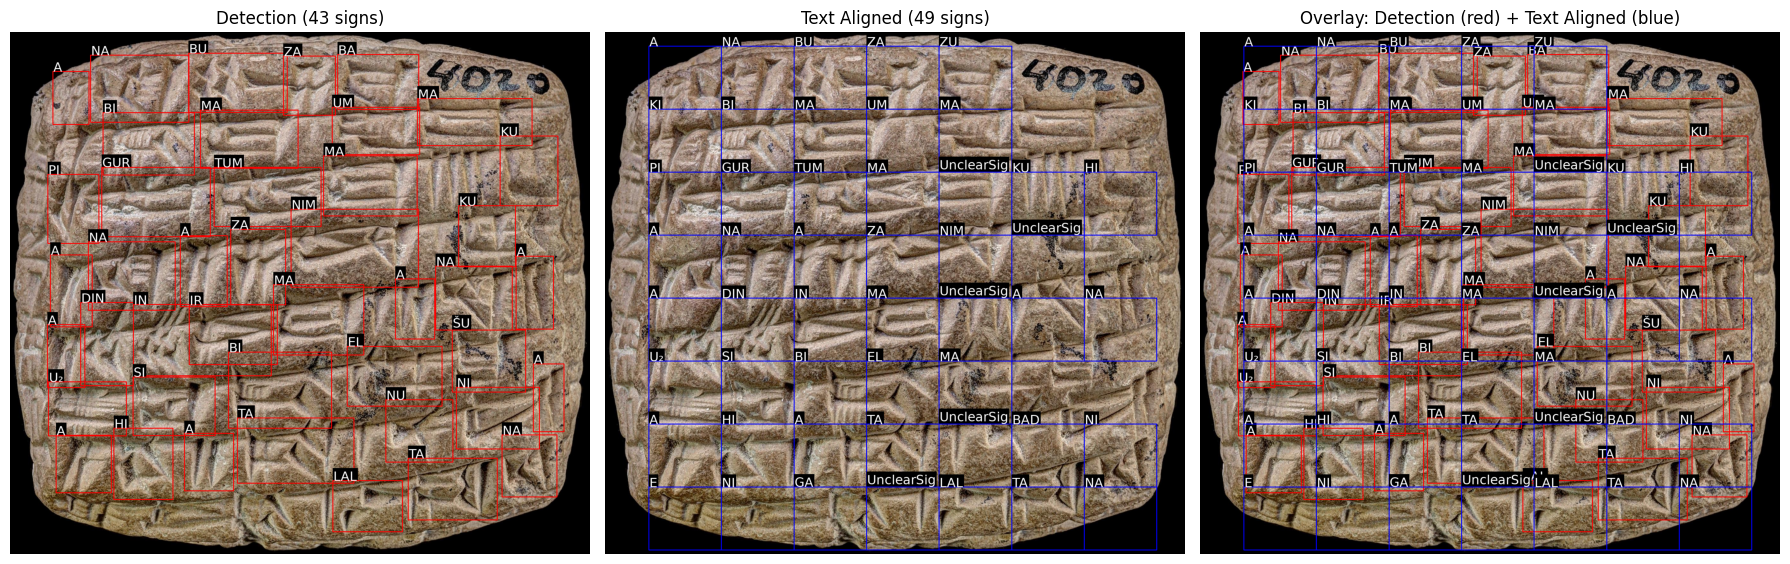

Red = Detection results, Blue = Text-aligned bboxes


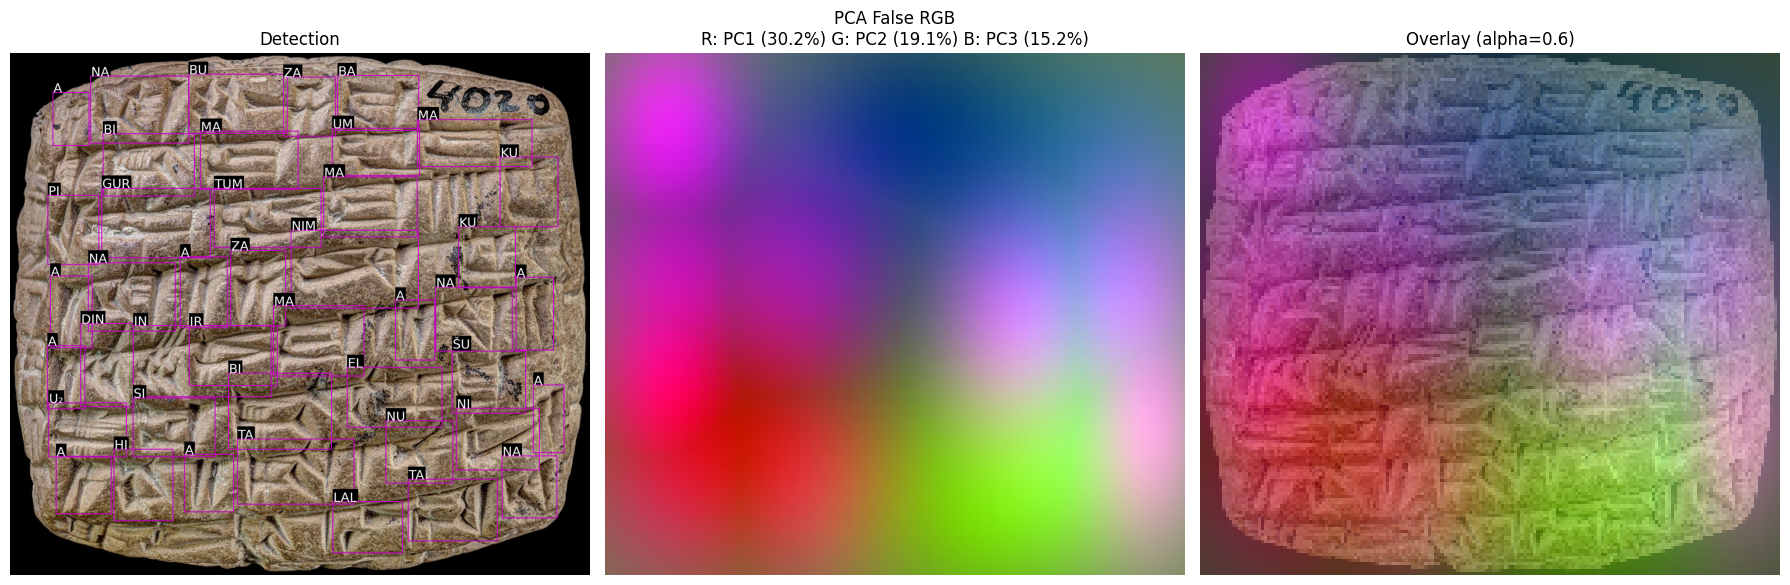

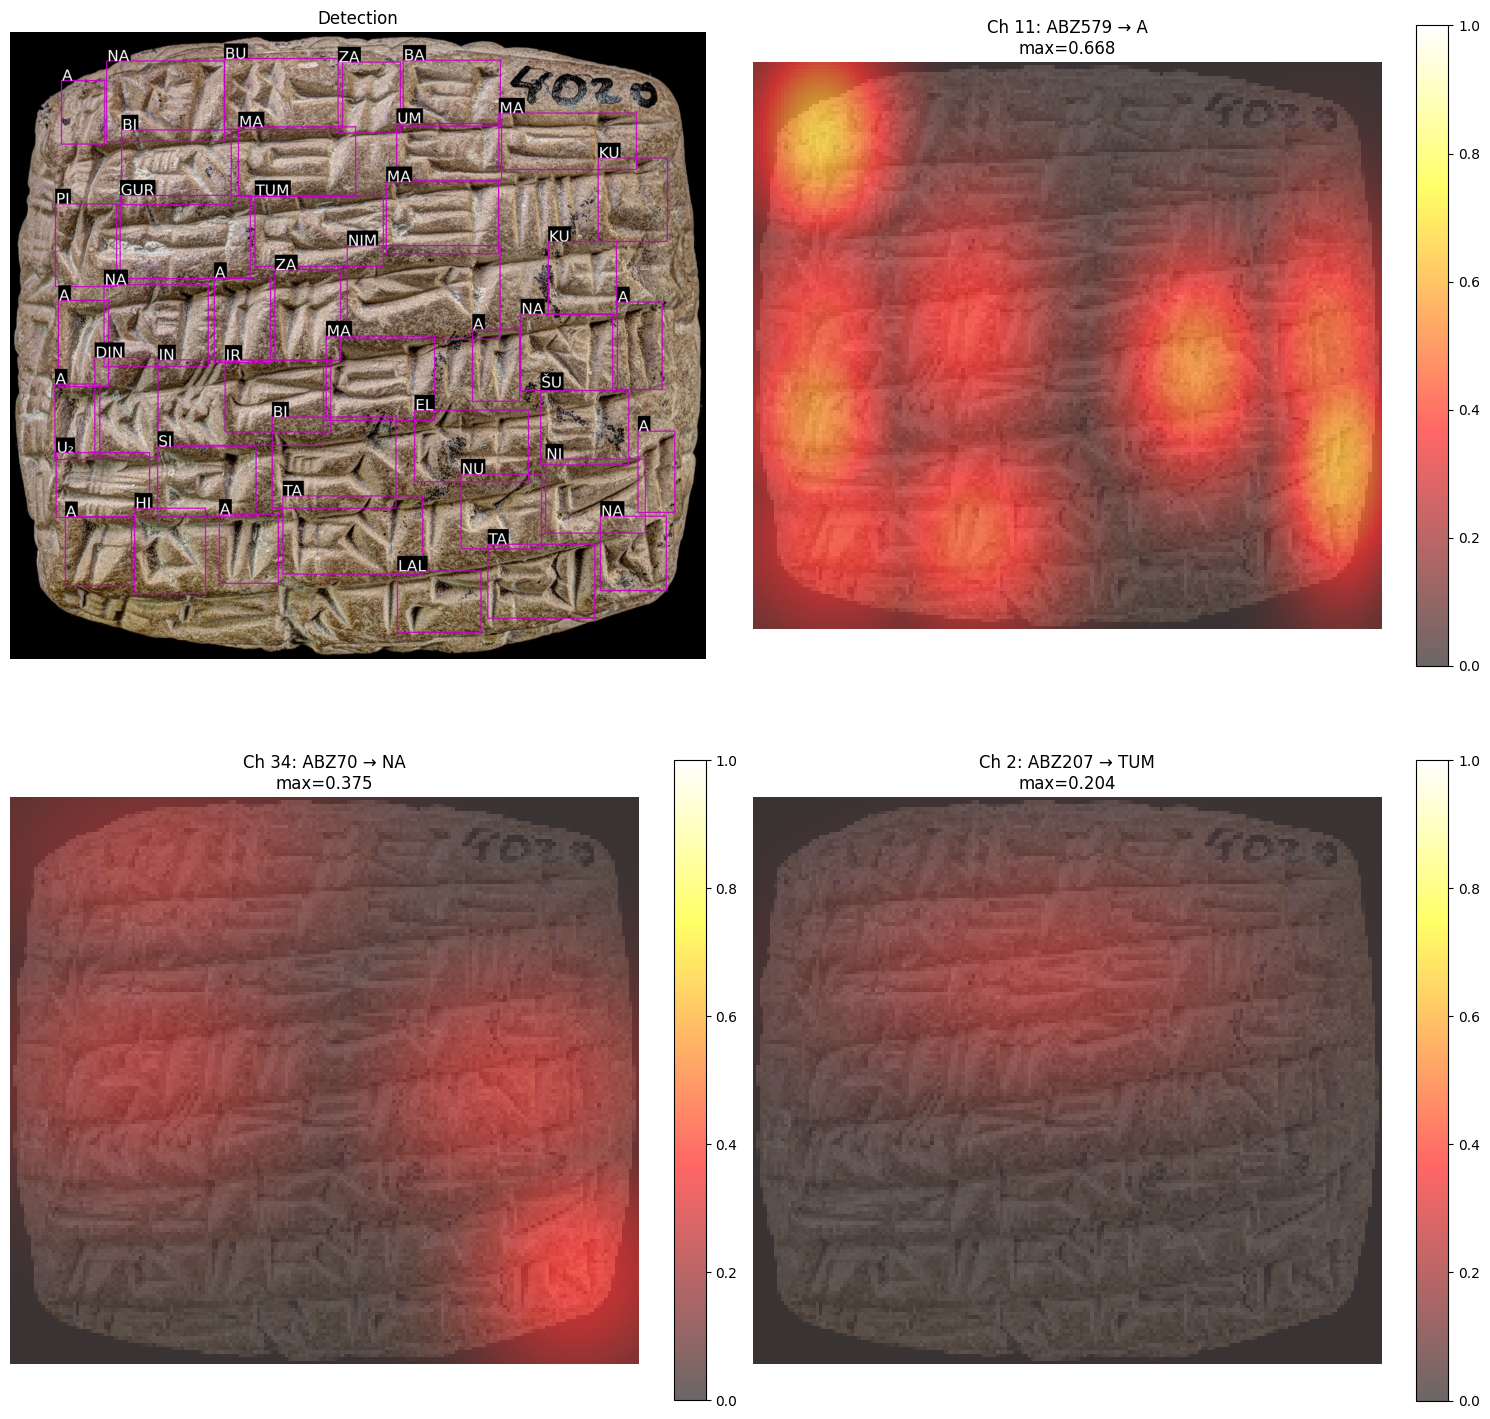

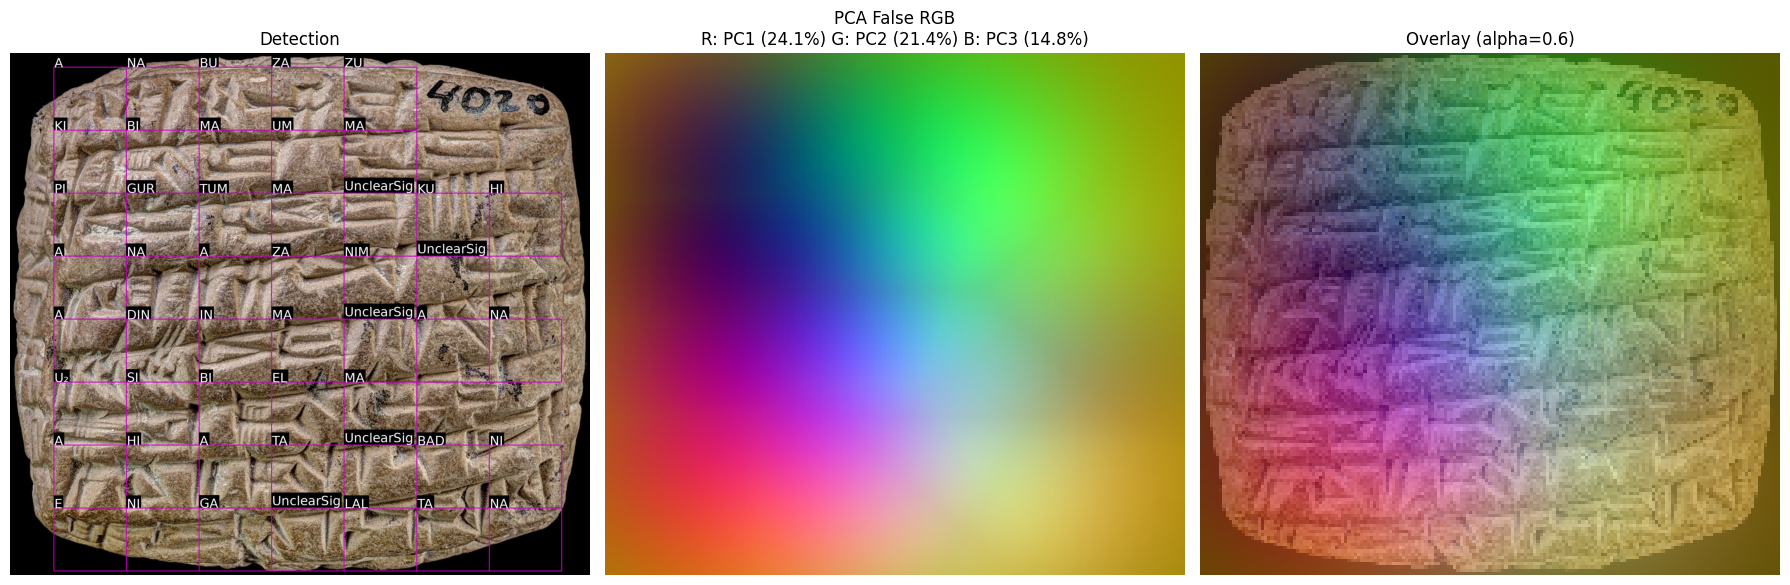

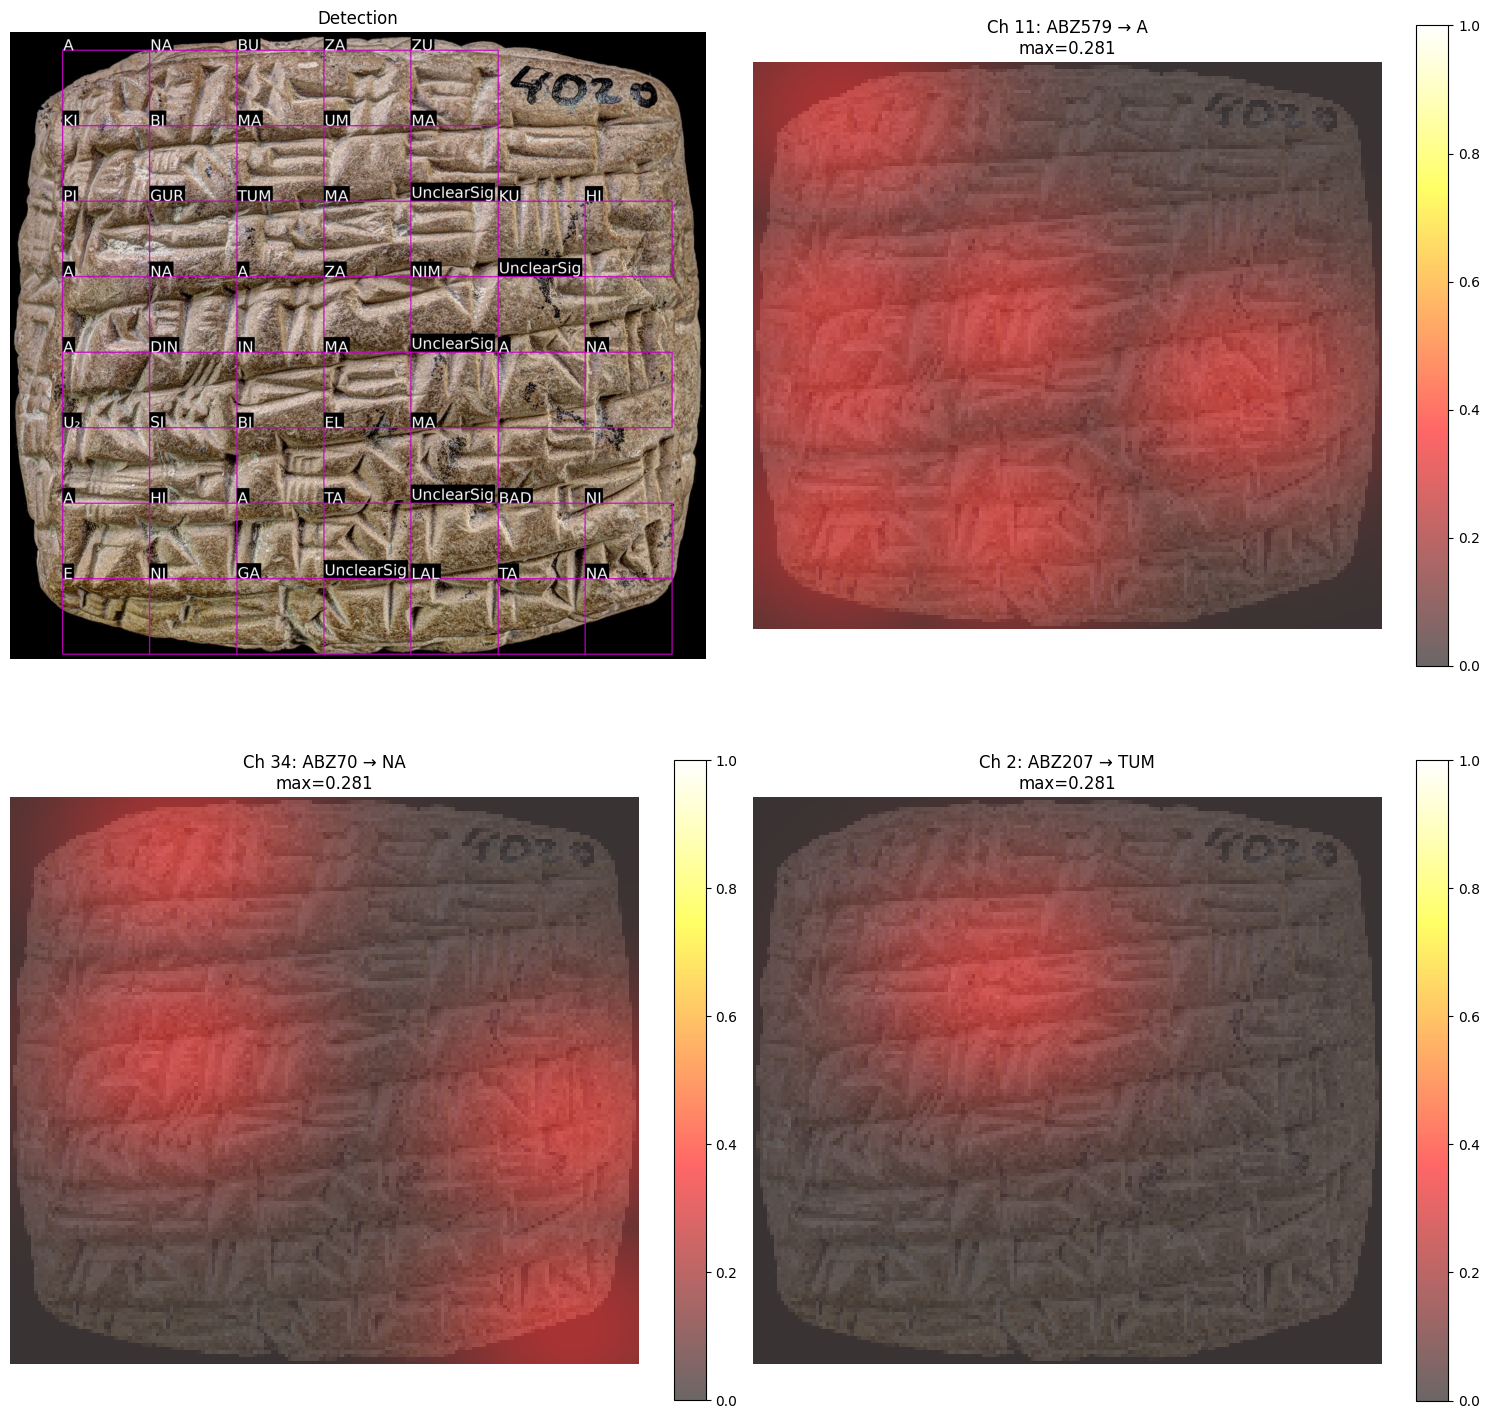

In [39]:
# 6. Visualize SubTablet data using existing visualizers
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Visualize detection SubTablet
det_vis = BboxVisualizer(color=(255, 0, 0))  # Red for detection
det_vis.draw_boxes(sub_tablet_detection.img.copy(), sub_tablet_detection.to_detection_list())
axes[0].imshow(cv2.cvtColor(det_vis.result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Detection ({len(sub_tablet_detection)} signs)")
axes[0].axis('off')

# Visualize text-aligned SubTablet
text_vis = BboxVisualizer(color=(0, 0, 255))  # Blue for text-aligned
text_vis.draw_boxes(sub_tablet_text_aligned.img.copy(), sub_tablet_text_aligned.to_detection_list())
axes[1].imshow(cv2.cvtColor(text_vis.result, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Text Aligned ({len(sub_tablet_text_aligned)} signs)")
axes[1].axis('off')

# Overlay both on same image
det_overlay = BboxVisualizer(color=(255, 0, 0))  # Red for detection
det_overlay.draw_boxes(sub_tablet_detection.img.copy(), sub_tablet_detection.to_detection_list())
text_overlay = BboxVisualizer(color=(0, 0, 255))  # Blue for text
text_overlay.draw_boxes(det_overlay.result, sub_tablet_text_aligned.to_detection_list())
axes[2].imshow(cv2.cvtColor(text_overlay.result, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Overlay: Detection (red) + Text Aligned (blue)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("Red = Detection results, Blue = Text-aligned bboxes")

heatmap_visualizer_opt = HeatmapVisualizer(bbox_color=(200, 0, 200))
heatmap_visualizer_opt.draw_pca(sub_tablet_detection.img, sub_tablet_detection.heatmap, detection=sub_tablet_detection.to_detection_list())
heatmap_visualizer_opt.display_result(vis_opt="draw")
heatmap_visualizer_opt.draw_channels(sub_tablet_detection.img, sub_tablet_detection.heatmap, channels=(class_id_for_A, class_id_for_NA, 2), detection=sub_tablet_detection.to_detection_list())
heatmap_visualizer_opt.display_result(vis_opt="draw")

heatmap_visualizer_opt.draw_pca(sub_tablet_text_aligned.img, sub_tablet_text_aligned.heatmap, detection=sub_tablet_text_aligned.to_detection_list())
heatmap_visualizer_opt.display_result(vis_opt="draw")
heatmap_visualizer_opt.draw_channels(sub_tablet_text_aligned.img, sub_tablet_text_aligned.heatmap, channels=(class_id_for_A, class_id_for_NA, 2), detection=sub_tablet_text_aligned.to_detection_list())
heatmap_visualizer_opt.display_result(vis_opt="draw")

In [41]:
# 7. Elastic Chain Optimization - Refine text-aligned bboxes using detection heatmap
from sign_alignment import ElasticChainOptimizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

optimizer = ElasticChainOptimizer(
    sub_tablet_text=sub_tablet_text_aligned,
    detection_heatmap=sub_tablet_detection.heatmap,
    scale_factor=scale_factor,
    lambda_data=10000.0,
    lambda_seq=0.05,
    lambda_smooth=0.15,
    lambda_anchor=0.05,
    prior_aspect_ratio=avg_width / avg_height,
    device=device
)

print(f"=== Elastic Chain Optimizer Initialized ===")
print(f"  Device: {optimizer.device}")
print(f"  Number of signs: {optimizer.num_signs}")
print(f"  Number of rows: {optimizer.num_rows}")
print(f"  Prior aspect ratio: {optimizer.prior_aspect_ratio:.3f}")
print(f"  Heatmap shape: {optimizer.heatmap.shape}")

# Run optimization
sub_tablet_optimized = optimizer.optimize(
    num_iterations=100,
    lr=5.0,
    verbose=True,
    log_every=5
)

=== Elastic Chain Optimizer Initialized ===
  Device: cuda
  Number of signs: 49
  Number of rows: 8
  Prior aspect ratio: 1.154
  Heatmap shape: torch.Size([163, 181, 173])
Starting optimization with 49 signs, 8 rows
Lambdas: data=10000.0, seq=0.05, smooth=0.15, anchor=0.05
Iter    0: L_total=-2017.3906, L_data=-0.2017, L_seq=0.0000, L_smooth=0.0000, L_anchor=0.0000
Iter    5: L_total=-2080.0710, L_data=-0.2100, L_seq=77.9495, L_smooth=39.9814, L_anchor=206.7957
Iter   10: L_total=-2117.7124, L_data=-0.2147, L_seq=96.2828, L_smooth=25.4112, L_anchor=411.0263
Iter   15: L_total=-2138.0522, L_data=-0.2168, L_seq=62.8848, L_smooth=31.7989, L_anchor=444.7075
Iter   20: L_total=-2149.6309, L_data=-0.2175, L_seq=77.9541, L_smooth=22.5677, L_anchor=368.8827
Iter   25: L_total=-2155.3667, L_data=-0.2176, L_seq=66.4607, L_smooth=18.5376, L_anchor=296.4318
Iter   30: L_total=-2157.7573, L_data=-0.2177, L_seq=60.2128, L_smooth=17.2630, L_anchor=275.8166
Iter   35: L_total=-2160.3369, L_data=-0.2

In [42]:
# 7.5 Debug: Analyze data loss gradient and heatmap values

test_optimizer = ElasticChainOptimizer(
    sub_tablet_text=sub_tablet_text_aligned,
    detection_heatmap=sub_tablet_detection.heatmap,
    scale_factor=scale_factor,
    lambda_data=1.0,
    lambda_seq=0.0,
    lambda_smooth=0.0,
    lambda_anchor=0.0,
    device=device
)

# Compute loss and gradients
loss = test_optimizer.compute_data_loss()
loss.backward()

grads = test_optimizer.params.grad
print("=== Data Loss Gradient Analysis ===")
print(f"L_data = {loss.item():.4f}")
print(f"Gradient statistics:")
print(f"  cx grad: mean={grads[:, 0].mean().item():.6f}, std={grads[:, 0].std().item():.6f}, max={grads[:, 0].abs().max().item():.6f}")
print(f"  cy grad: mean={grads[:, 1].mean().item():.6f}, std={grads[:, 1].std().item():.6f}, max={grads[:, 1].abs().max().item():.6f}")
print(f"  w grad:  mean={grads[:, 2].mean().item():.6f}, std={grads[:, 2].std().item():.6f}")
print(f"  h grad:  mean={grads[:, 3].mean().item():.6f}, std={grads[:, 3].std().item():.6f}")

# Analyze heatmap values at sign positions
print("\n=== Heatmap Values at Text-Aligned Sign Positions ===")
heatmap_h, heatmap_w = sub_tablet_detection.heatmap.shape[:2]
values_at_positions = []

for i, sb in enumerate(sub_tablet_text_aligned.sign_boxes[:10]):
    if sb.abz_name in CLASSES_ABZ:
        class_id = CLASSES_ABZ.index(sb.abz_name)
    else:
        continue
    
    sx = int(sb.cx / scale_factor)
    sy = int(sb.cy / scale_factor)
    
    if 0 <= sy < heatmap_h and 0 <= sx < heatmap_w:
        val = sub_tablet_detection.heatmap[sy, sx, class_id]
        values_at_positions.append(val)
        print(f"  {i+1}. {sb.sign_name} (class_id={class_id}): pos=({sx},{sy}), heatmap_val={val:.4f}")

print(f"\nMean heatmap value at text positions: {np.mean(values_at_positions):.4f}")
print(f"Max heatmap value at text positions: {np.max(values_at_positions):.4f}")

# Check heatmap max values for these classes
print("\n=== Max Heatmap Values for Each Class ===")
for i, sb in enumerate(sub_tablet_text_aligned.sign_boxes[:5]):
    if sb.abz_name in CLASSES_ABZ:
        class_id = CLASSES_ABZ.index(sb.abz_name)
        max_val = sub_tablet_detection.heatmap[:, :, class_id].max()
        print(f"  {sb.sign_name} (class_id={class_id}): max_heatmap={max_val:.4f}")

=== Data Loss Gradient Analysis ===
L_data = -0.2017
Gradient statistics:
  cx grad: mean=0.000004, std=0.000010, max=0.000036
  cy grad: mean=-0.000000, std=0.000005, max=0.000016
  w grad:  mean=0.000000, std=0.000000
  h grad:  mean=0.000000, std=0.000000

=== Heatmap Values at Text-Aligned Sign Positions ===
  1. A (class_id=11): pos=(25,14), heatmap_val=0.5893
  2. NA (class_id=34): pos=(47,14), heatmap_val=0.1913
  3. BU (class_id=91): pos=(70,14), heatmap_val=0.2190
  4. ZA (class_id=10): pos=(93,14), heatmap_val=0.4138
  5. ZU (class_id=70): pos=(116,14), heatmap_val=0.0000
  6. KI (class_id=45): pos=(25,34), heatmap_val=0.0000
  7. BI (class_id=52): pos=(47,34), heatmap_val=0.2240
  8. MA (class_id=21): pos=(70,34), heatmap_val=0.2236
  9. UM (class_id=113): pos=(93,34), heatmap_val=0.2566
  10. MA (class_id=21): pos=(116,34), heatmap_val=0.1928

Mean heatmap value at text positions: 0.2310
Max heatmap value at text positions: 0.5893

=== Max Heatmap Values for Each Class ===


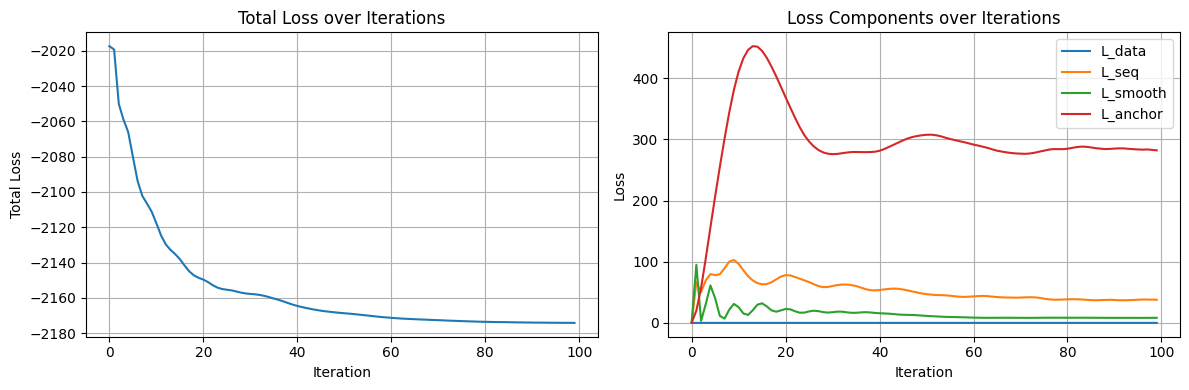

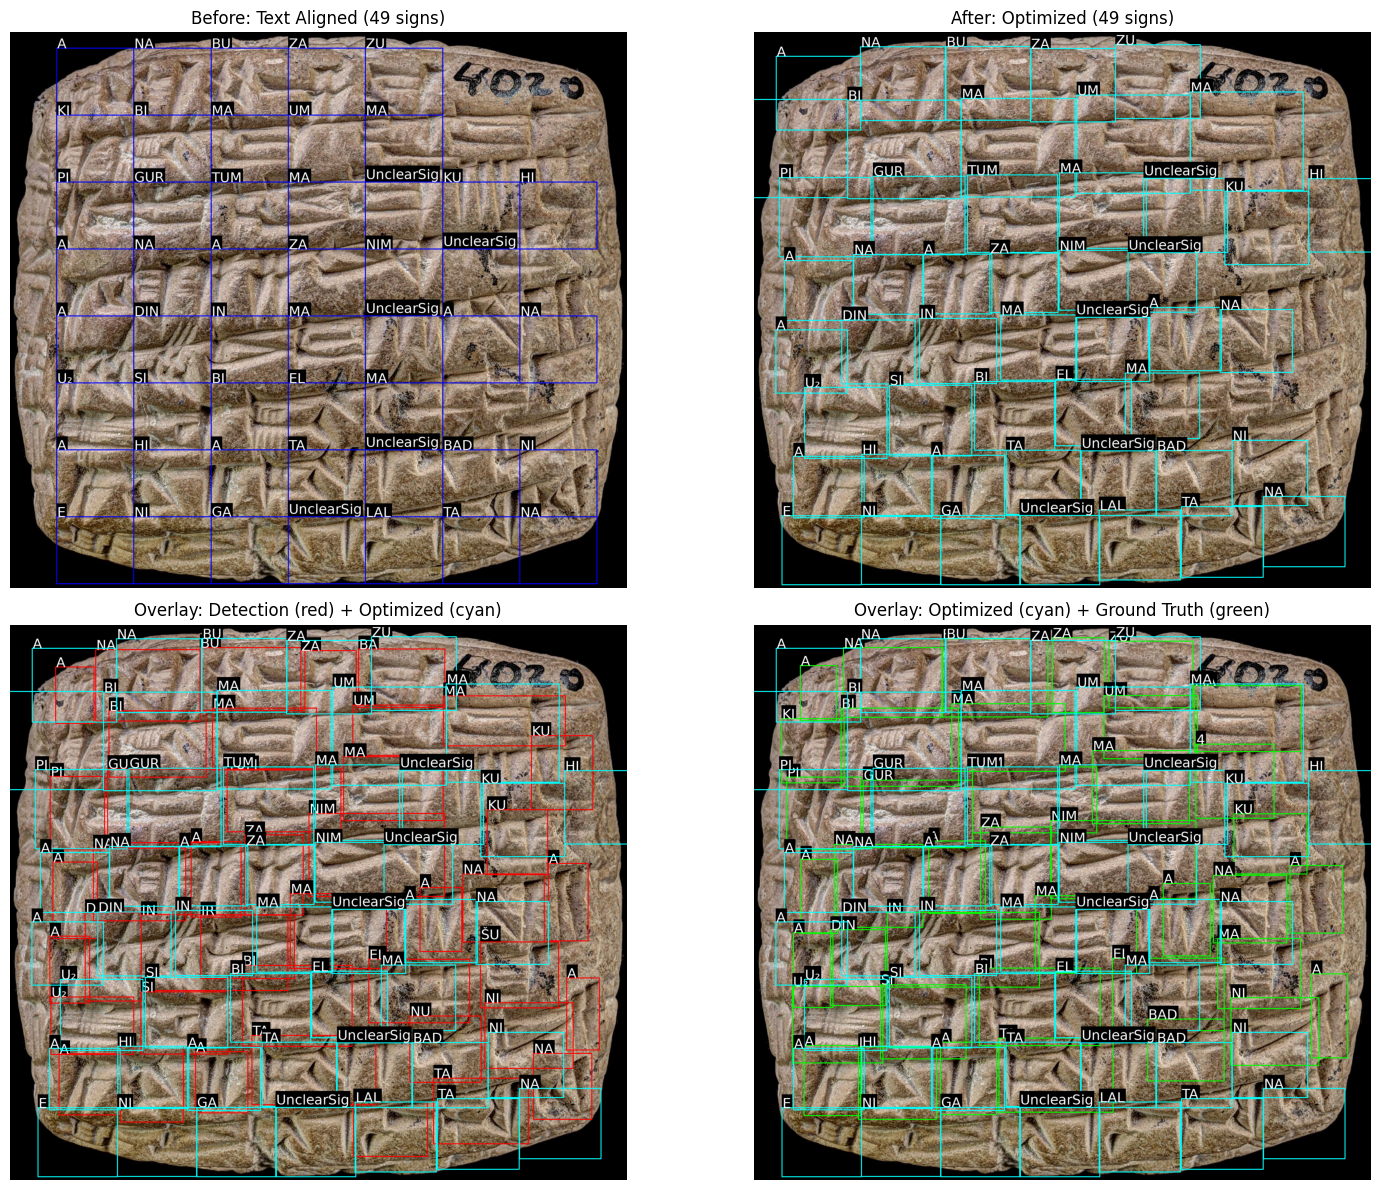

Blue = Text-aligned (before), Cyan = Optimized (after), Red = Detection, Green = Ground Truth


In [43]:
# 8. Visualize Optimization Results

# Plot loss history
optimizer.plot_loss_history()

# Visualize comparison: before vs after optimization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Before: Text-aligned (blue)
before_vis = BboxVisualizer(color=(0, 0, 255))
before_vis.draw_boxes(sub_tablet_text_aligned.img.copy(), sub_tablet_text_aligned.to_detection_list())
axes[0, 0].imshow(cv2.cvtColor(before_vis.result, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f"Before: Text Aligned ({len(sub_tablet_text_aligned)} signs)")
axes[0, 0].axis('off')

# After: Optimized (cyan)
after_vis = BboxVisualizer(color=(0, 255, 255))
after_vis.draw_boxes(sub_tablet_optimized.img.copy(), sub_tablet_optimized.to_detection_list())
axes[0, 1].imshow(cv2.cvtColor(after_vis.result, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f"After: Optimized ({len(sub_tablet_optimized)} signs)")
axes[0, 1].axis('off')

# Overlay: Detection (red) + Optimized (cyan)
det_vis_overlay = BboxVisualizer(color=(255, 0, 0))
det_vis_overlay.draw_boxes(sub_tablet_detection.img.copy(), sub_tablet_detection.to_detection_list())
opt_vis_overlay = BboxVisualizer(color=(0, 255, 255))
opt_vis_overlay.draw_boxes(det_vis_overlay.result, sub_tablet_optimized.to_detection_list())
axes[1, 0].imshow(cv2.cvtColor(opt_vis_overlay.result, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title(f"Overlay: Detection (red) + Optimized (cyan)")
axes[1, 0].axis('off')

# Overlay: Optimized + Ground Truth
gt_vis_overlay = BboxVisualizer(color=(0, 255, 0))  # green for ground truth
gt_vis_overlay.draw_boxes(sub_tablet_optimized.img.copy(), gt_boxes_exp)
opt_vis_overlay_gt = BboxVisualizer(color=(0, 255, 255))  # cyan for optimized
opt_vis_overlay_gt.draw_boxes(gt_vis_overlay.result, sub_tablet_optimized.to_detection_list())
axes[1, 1].imshow(cv2.cvtColor(opt_vis_overlay_gt.result, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f"Overlay: Optimized (cyan) + Ground Truth (green)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("Blue = Text-aligned (before), Cyan = Optimized (after), Red = Detection, Green = Ground Truth")

In [44]:
# 9. Analyze Parameter Changes

# Get parameter changes
param_changes = optimizer.get_param_changes()

print("=== Parameter Changes Summary ===")
print(f"  Mean delta_cx: {param_changes[:, 0].mean():.2f} (std: {param_changes[:, 0].std():.2f})")
print(f"  Mean delta_cy: {param_changes[:, 1].mean():.2f} (std: {param_changes[:, 1].std():.2f})")
print(f"  Mean delta_w:  {param_changes[:, 2].mean():.2f} (std: {param_changes[:, 2].std():.2f})")
print(f"  Mean delta_h:  {param_changes[:, 3].mean():.2f} (std: {param_changes[:, 3].std():.2f})")

# Compare first few signs before/after
print("\n=== First 5 Signs: Before vs After ===")
for i in range(min(5, len(sub_tablet_text_aligned.sign_boxes))):
    before = sub_tablet_text_aligned.sign_boxes[i]
    after = sub_tablet_optimized.sign_boxes[i]
    print(f"  {i+1}. {before.sign_name}:")
    print(f"      Before: cx={before.cx:.1f}, cy={before.cy:.1f}, w={before.width:.1f}, h={before.height:.1f}")
    print(f"      After:  cx={after.cx:.1f}, cy={after.cy:.1f}, w={after.width:.1f}, h={after.height:.1f}")
    print(f"      Delta:  Δcx={after.cx-before.cx:.1f}, Δcy={after.cy-before.cy:.1f}, Δw={after.width-before.width:.1f}, Δh={after.height-before.height:.1f}")

=== Parameter Changes Summary ===
  Mean delta_cx: -24.06 (std: 93.62)
  Mean delta_cy: -0.94 (std: 16.76)
  Mean delta_w:  13.53 (std: 36.46)
  Mean delta_h:  11.70 (std: 31.38)

=== First 5 Signs: Before vs After ===
  1. A:
      Before: cx=251.0, cy=145.8, w=227.3, h=197.0
      After:  cx=190.1, cy=179.9, w=249.6, h=216.4
      Delta:  Δcx=-61.0, Δcy=34.1, Δw=22.2, Δh=19.5
  2. NA:
      Before: cx=478.4, cy=145.8, w=227.3, h=197.0
      After:  cx=438.7, cy=152.2, w=250.2, h=216.6
      Delta:  Δcx=-39.7, Δcy=6.4, Δw=22.9, Δh=19.7
  3. BU:
      Before: cx=705.7, cy=145.8, w=227.3, h=197.0
      After:  cx=690.6, cy=151.3, w=250.4, h=216.8
      Delta:  Δcx=-15.1, Δcy=5.4, Δw=23.0, Δh=19.9
  4. ZA:
      Before: cx=933.1, cy=145.8, w=227.3, h=197.0
      After:  cx=939.7, cy=156.5, w=249.9, h=216.7
      Delta:  Δcx=6.7, Δcy=10.7, Δw=22.6, Δh=19.7
  5. ZU:
      Before: cx=1160.4, cy=145.8, w=227.3, h=197.0
      After:  cx=1189.8, cy=145.8, w=250.1, h=216.6
      Delta:  Δcx=29.